In [1]:
import torch 
import torch.nn as nn

In [2]:
import numpy as np

In [3]:
from basemodel import *

In [4]:
from data_handler import *

In [5]:
from optimizer import *
from scheduler import *

In [6]:
from fit import *

In [7]:
import matplotlib.pyplot as plt

In [8]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [9]:
import cbs

In [10]:
from unet import Unet_sigmoid

In [11]:
from collections import OrderedDict

In [12]:
import random

In [13]:
import unet_ein as ue

In [14]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

In [15]:
from torch.distributions import normal

In [16]:
import pytorch_ssim

# Data

In [17]:
trn_ , val_ = split('../dataset/fuz attack/lka_can/normal/bin/',prc = 0.01, dataset_pct=  1, dim =(112,112), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

In [18]:
trn_.data= trn_.data[80*220:]

In [19]:
bs = 8
seq_len = 10
overlap=0

In [20]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
v4_val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [21]:
v4_anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [22]:
dl =CombineDataLoader(trn_dl,v4_val_dl)

# Custom Loss

In [23]:
class SSIM:
    def __init__(self):
        self.ssim_loss = pytorch_ssim.SSIM(window_size = 11)
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka= ip
        tgt_lka = tgt_lka [None,None,None,:]
        ip_lka = ip_lka [None,None,None,:]
        
        lka = self.ssim_loss(ip_lka,tgt_lka)
        return 1-(lka)

In [24]:
class mse:
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka = ip
        
        #vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
        #lka = nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        lka = nn.functional.mse_loss(ip_lka,tgt_lka)
        return lka

In [25]:
class binary:
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka = ip
        
        #vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
        #lka = nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        lka = nn.functional.binary_cross_entropy(ip_lka,tgt_lka)
        return lka

In [26]:
loss = SSIM()

## Helping methods

In [27]:
def get_vis(frame):
    binary_value = torch.cat((frame[-4:],frame[:8]))
    new_frame = frame.type(torch.int).tolist()
    new_frame = [str(i) for i in new_frame]
    s = ''.join(new_frame)
    binary_value_str = s[-4:] + s[:8]
    
    return binary_value,torch.tensor([max(0.0,(int(binary_value_str,2) *0.01)-16)])

In [28]:
def normalize(value):
    return torch.abs(value / 4).cuda()

In [29]:
def diff_avg(l,window):
    l = torch.tensor(l)
    if len(l) < window and len(l)>1:
        return l.std()
    elif len(l)>window:
        return l[-window:].std()
    return torch.zeros(1)

# Model : Predective lka sequence
Input: Seq ( VIS , LKA) <br>
Input Form: Decimal <br>
Output: Prediction   10 LKA timestamps <br>
Training Dataset: Original<br>

In [ ]:

        
        

        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(m.lka.type(torch.BoolTensor),torch.ones_like(m.lka).type(torch.BoolTensor)).type(torch.LongTensor).cuda()
            

        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return self.lka.type(torch.FloatTensor).cuda(),self.vis.type(torch.FloatTensor).cuda(),out[:88].type(torch.FloatTensor).cuda(),out[88:]


In [93]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()

        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        

        self.vis_values = torch.tensor(np.random.normal(1.6737,0.3800,50)).tolist()
        self.vis_idx = []
        
        self.lka_values = [0]*50

        
        self.rep = nn.Sequential(nn.Linear(64,32),
                                    nn.PReLU(),
                                    nn.Dropout(0.5),
                                    nn.Linear(32,10),
                                    nn.Sigmoid())
        self.art_lka =[]
        self.values = []
        self.lstm = nn.LSTM(2,64,2,dropout=0.5)
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = False
        self.max_count= 2352
    def forward(self,x):   
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake',self.lka.device)
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()
            
        cat=torch.cat([self.lka,normalize(self.vis)])#.cuda()
        l = torch.tensor(self.lka_values[-50:-10]).type(torch.float).cuda()
        v = torch.tensor(self.vis_values[-50:-10]).cuda()
        
        stack = torch.stack([l,v]).view(40,1,2)
        
        op = self.lstm(stack)
        
        predected_lka = self.rep(op[-1][-1])
        #predected_lka = self.lka_compressor(cat*past_rep)
        
        self.previous_vis = self.vis.data.detach()
        self.previous_lka = self.lka.data.detach()
        #self.previous_states = history.data.detach()
        
        self.lka_values.append(self.lka.detach())
        
        self.values.append(cat)
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        
        return torch.tensor(self.lka_values[-10:]).view(-1).cuda(),predected_lka.view(-1)[-10:]


In [131]:
m =  unet_seq(bs,seq_len).cuda()

In [132]:
opt = torch.optim.Adam(m.parameters(),1e-12)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [133]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [134]:
#cbs.load_all('documentation/lka/lstm/1/', model=m , learn=learn,opt=opt, sched = sched)

In [135]:
loss = mse()

In [136]:
m.max_count = len(trn_dl)+len(v4_val_dl)

In [137]:
learn.fit(m , opt , 8 , dl,loss  ,callbacks=[sched])

  1%|          | 15/2326 [00:00<00:42, 53.94it/s, loss : 0.23661119143168133]

[2, 874, 992, 162, 354, 26, 939, 868, 525, 675, 430, 289, 592, 377, 834, 716, 229, 410, 218, 999, 500]
fake cuda:0


  2%|▏         | 45/2326 [00:00<00:29, 76.21it/s, loss : 0.2454463111029731] 

fake cuda:0


  7%|▋         | 173/2326 [00:01<00:21, 101.76it/s, loss : 0.2468809888542043] 

...

fake cuda:0


 40%|███▉      | 920/2326 [00:09<00:17, 80.71it/s, loss : 0.25183639526367185] 

fake cuda:0


 88%|████████▊ | 22/25 [00:00<00:00, 96.76it/s, loss : 0.2541039423509078]1183] 

train Loss:  0.25351962447166443   validation loss:  0.25410404801368713
tensor(nan)


In [138]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = l[2]

In [139]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


 10%|▉         | 225/2326 [00:01<00:16, 129.76it/s]

fake cuda:0


 22%|██▏       | 521/2326 [00:04<00:18, 98.24it/s] 

fake cuda:0


...

  1%|          | 9/1224 [00:00<00:13, 89.61it/s]

testing...


  5%|▌         | 63/1224 [00:00<00:09, 116.70it/s]

fake cuda:0


 99%|█████████▉| 1214/1224 [00:09<00:00, 120.66it/s]

In [140]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [141]:
lka = [i[0][0]for i in m.flag_list]

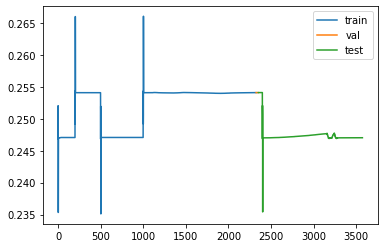

In [142]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

#ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [106]:
path = 'Models/publication/predict lka seq/mse/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

  0%|          | 8/2326 [00:00<00:30, 76.95it/s]

testing...


 32%|███▏      | 8/25 [00:00<00:00, 72.63it/s]0it/s]

testing...


  1%|          | 7/1224 [00:00<00:17, 68.26it/s]

...

  1%|          | 9/1224 [00:00<00:14, 83.38it/s]

testing...


  5%|▌         | 63/1224 [00:00<00:10, 114.77it/s]

fake cuda:0


 99%|█████████▉| 1213/1224 [00:09<00:00, 132.65it/s]

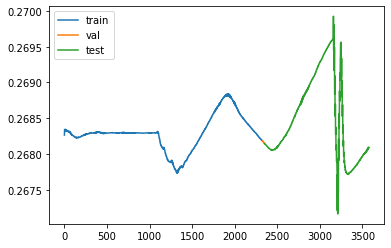

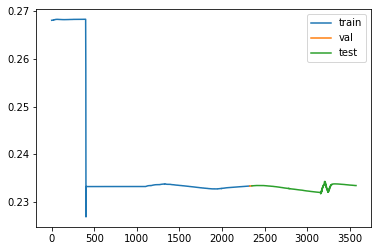

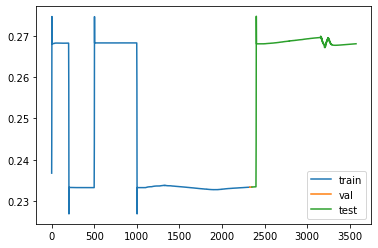

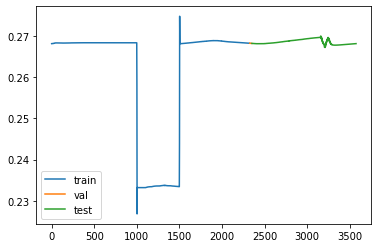

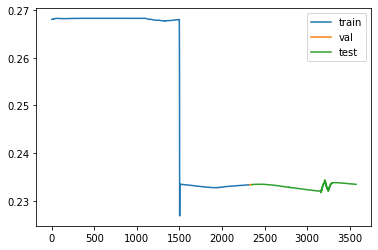

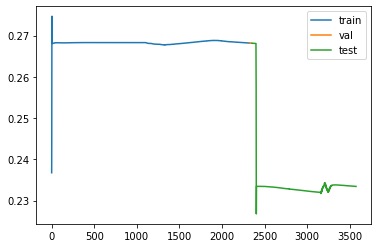

In [161]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.5 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/predict lka seq/mse/{i}/'
    #fig.savefig(f'{path}i.png')
    #save(path,[a,b,c],names=['normal','attack','train'])

In [101]:
max(b[0:100]),max(c[2:500])

(tensor(0.8113), tensor(0.8198))

In [102]:
lka = [i[0] for i in m.values]
vis = [i[1] for i in m.values]
#diff = [i[0][3] for i in m.lka_values]
#op = [i[1][0] for i in m.values]

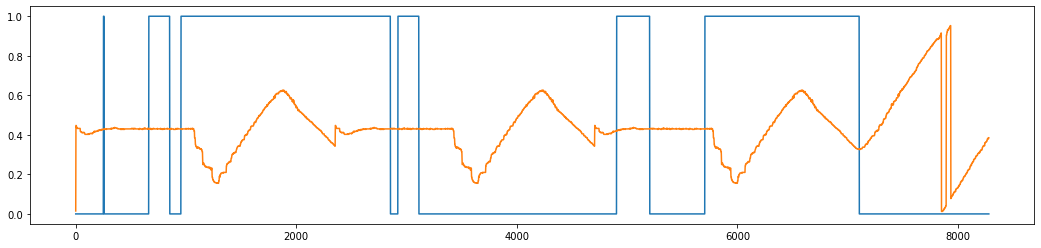

In [103]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
#ax.plot(range(len(op)),op)


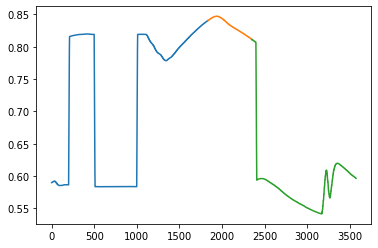

In [105]:
threshold = b[:100].max()
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))
ax.plot(range(len(c),len(c)+len(a)),list(a))
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b))
#ax.plot(range(len(lka)),lka)
#ax.plot(range(len(a)+len(b)+len(c)), [threshold]*(len(a)+len(b)+len(c)))

In [ ]:
path = 'Models/documentation/lka/lstm/1/'
#save(path,[a,b,c],names=['normal','attack','train'])

In [597]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)

# Model :LSTM
Input: Seq ( VIS , LKA) <br>
Input Form: Decimal <br>
Output: Prediction   5 LKA timestamps <br>
Training Dataset: Original<br>

In [155]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()

        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.lka_compressor = nn.Sequential(nn.Linear(2,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,8),
                                            nn.PReLU(),
                                            nn.Dropout(0.25),
                                            nn.Linear(8,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.25),
                                            nn.Linear(16,2),
                                            nn.Sigmoid())

        self.vis_values = torch.tensor(np.random.normal(1.6737,0.3800,50)).tolist()
        self.vis_idx = []
        
        self.lka_values = [0]*50

        
        self.rep = nn.Sequential(nn.Linear(64,32),
                                    nn.PReLU(),
                                    nn.Dropout(0.25),
                                    nn.Linear(32,5),
                                    nn.Sigmoid())
        self.art_lka =[]
        self.values = []
        self.lstm = nn.LSTM(2,64,2,dropout=0.8)
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = False
        self.max_count= 2352
    def forward(self,x):   
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        if self.c==0 and not self.test:
            idx = random.randint(0,50)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake',self.lka.device)
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()
            
        cat=torch.cat([self.lka,normalize(self.vis)])#.cuda()
        l = torch.tensor(self.lka_values[-50:-5]).type(torch.float).cuda()
        v = torch.tensor(self.vis_values[-50:-5]).cuda()
        
        stack = torch.stack([l,v]).view(45,1,2)
        
        op = self.lstm(stack)
        
        predected_lka = self.rep(op[-1][-1])
        #predected_lka = self.lka_compressor(cat*past_rep)
        
        self.previous_vis = self.vis.data.detach()
        self.previous_lka = self.lka.data.detach()
        #self.previous_states = history.data.detach()
        
        self.lka_values.append(self.lka.detach())
        
        self.values.append(cat)
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        
        return torch.tensor(self.lka_values[-5:]).view(-1).cuda(),predected_lka.view(-1)[-5:]


In [265]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(2,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,8),
                                            nn.PReLU(),
                                            nn.Dropout(0.25),
                                            nn.Linear(8,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.25),
                                            nn.Linear(16,2),
                                            nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c = 0
        
        self.vis_values = torch.tensor(np.random.normal(1.6737,0.3800,50)).tolist()
        self.vis_idx = []
        
        self.lka_values = [0]*50
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        
        self.rep = nn.Sequential(nn.Linear(64,32),
                                    nn.PReLU(),
                                    nn.Dropout(0.25),
                                    nn.Linear(32,5),
                                    nn.Sigmoid())
        self.art_lka =[]
        self.values = []
        self.lstm = nn.LSTM(2,64,2,dropout=0.8)
    def forward(self,x):   
        self.c = (self.c+1) % self.max_count
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
        
        if self.c == 1 :
            self.vis_values = torch.tensor(np.random.normal(1.6737,0.3800,50)).tolist()
            self.art_lka =[]
            print('in')
            idx = random.randint(0,50)
            if idx  != 0:
                self.art_lka = torch.randint(0,1000,(1,(idx*2))).tolist()[0]
            print(self.art_lka)
            
        if   self.c in self.art_lka :
            #[1000,1300]
            #[2400]
            #[10,20,30,2400]
            #[20,30,50,2400]
            #[10,20,30]
            #lka_idx.size or self.c in self.art_lka
            #[0,20,30,35,45,48,50,60,68,70,75,80,95,100,150,180,230,250,300,320,333,350,390,400,480]
            ## Exception
            #if self.c in [2399,2400]:
            #    pass
            if self.lka[0]:
                print('LKA OFF',self.c)
                self.lka = torch.zeros(1).cuda()
            else:
                print('LKA ON',self.c)
                self.lka = torch.ones(1).cuda()
        
        #history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        #diff_mean = diff_avg(self.vis_values,100)
        
        #past_rep
        
        #past_rep = self.rep((torch.tensor(self.vis_values[-50:]).cuda()+self.lka) * normalize(self.vis))
        
        #left_lane = torch.tensor(4-self.vis-0.5).cuda()
        #previous_left_lane = torch.tensor(4-self.previous_vis-0.5).cuda()
        cat=torch.cat([self.lka,normalize(self.vis)])#.cuda()
        l = torch.tensor(self.lka_values[-50:-5]).type(torch.float).cuda()
        v = torch.tensor(self.vis_values[-50:-5]).cuda()
        
        stack = torch.stack([l,v]).view(45,1,2)
        
        op = self.lstm(stack)
        
        predected_lka = self.rep(op[-1][-1])
        #predected_lka = self.lka_compressor(cat*past_rep)
        
        self.previous_vis = self.vis.data.detach()
        self.previous_lka = self.lka.data.detach()
        #self.previous_states = history.data.detach()
        
        self.lka_values.append(self.lka.detach())
        self.values.append(cat)
        
        return torch.tensor(self.lka_values[-5:]).view(-1).cuda(),predected_lka.view(-1)[:5]


In [156]:
m =  unet_seq(bs,seq_len).cuda()

In [157]:
opt = torch.optim.Adam(m.parameters(),1e-12)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [158]:
trn_item = Validate(trn_dl)

In [159]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [160]:
cbs.load_all('documentation/lka/lstm/1/', model=m , learn=learn,opt=opt, sched = sched)

In [270]:
m.max_count = 2352

In [271]:
loss = mse()

In [272]:
learn.fit(m , opt , 8 , dl,loss  ,callbacks=[sched])

  1%|          | 14/2326 [00:00<01:04, 36.03it/s, loss : 0.23931046894618443]

in
[444, 133, 222, 434, 41, 262, 38, 162, 336, 90, 416, 43]


  2%|▏         | 55/2326 [00:00<00:32, 69.68it/s, loss : 0.2497459585016424] 

LKA ON 38
LKA OFF 41
LKA ON 43


  5%|▍         | 106/2326 [00:01<00:24, 92.41it/s, loss : 0.2478202244020858]

...

LKA OFF 465
LKA ON 468
LKA OFF 483


 22%|██▏       | 516/2326 [00:05<00:18, 99.55it/s, loss : 0.24771845617959665]

LKA ON 492


 80%|████████  | 20/25 [00:00<00:00, 87.96it/s, loss : 0.2414146900177002]92385]

train Loss:  0.2425246685743332   validation loss:  0.24143126606941223
tensor(nan)


In [273]:
len(trn_dl)+len(v4_val_dl)+len(v4_anml_dl)

3575

In [274]:
m.lka =torch.zeros(1).cuda()
#m.vis_values = []
m.c =0
m.max_count = 3576
m.values = []

In [275]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 0/2326 [00:00<?, ?it/s]

testing...


  0%|          | 3/2326 [00:00<01:22, 28.16it/s]

in
[174, 430, 336, 478, 296, 340, 394, 324, 297, 489, 264, 296, 210, 494, 267, 28, 208, 450, 269, 256, 395, 218, 60, 443, 420, 170, 271, 312, 441, 411, 261, 485, 472, 3, 353, 378, 185, 469, 363, 446, 272, 453, 210, 265, 276, 394, 43, 20, 387, 176, 210, 345, 282, 115, 379, 72, 368, 67, 228, 209, 154, 377, 164, 337, 474, 306, 279, 171, 228, 325, 189, 309, 59, 44, 177, 343, 460, 13, 429, 114, 441, 70, 49, 371, 127, 81, 356, 89, 126, 294, 80, 495, 455, 251, 225, 131]
LKA ON 3
LKA OFF 13


  1%|          | 16/2326 [00:00<01:02, 36.68it/s]

...

 20%|██        | 469/2326 [00:03<00:15, 123.38it/s]

LKA OFF 446
LKA ON 450
LKA OFF 453
LKA ON 455
LKA OFF 460
LKA ON 469


 21%|██▏       | 495/2326 [00:04<00:14, 124.52it/s]

LKA OFF 472
LKA ON 474
LKA OFF 478
LKA ON 485
LKA OFF 489
LKA ON 494
LKA OFF 495


100%|█████████▉| 2318/2326 [00:18<00:00, 127.37it/s]

In [276]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

 20%|██        | 5/25 [00:00<00:00, 49.05it/s]

testing...


  1%|          | 7/1224 [00:00<00:17, 67.81it/s]

testing...


 99%|█████████▉| 1214/1224 [00:09<00:00, 120.10it/s]

In [277]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [278]:
max(b[0:100]),max(c[2:500])

(tensor(0.2588), tensor(0.2596))

In [279]:
lka = [i[0] for i in m.values]
vis = [i[1] for i in m.values]
#diff = [i[0][3] for i in m.lka_values]
#op = [i[1][0] for i in m.values]

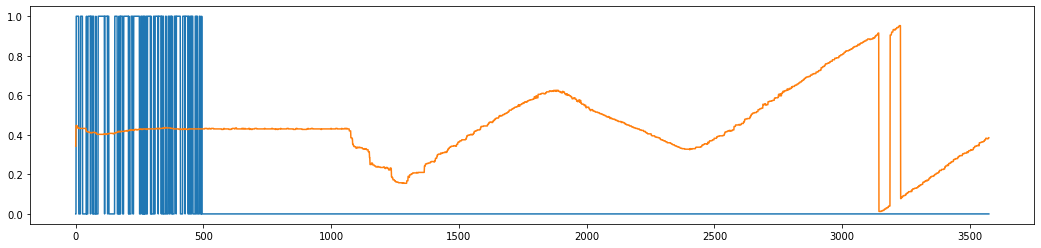

In [280]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
#ax.plot(range(len(op)),op)


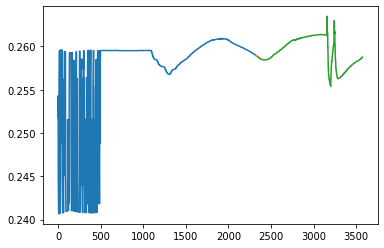

In [281]:
threshold = b[:100].max()
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))
ax.plot(range(len(c),len(c)+len(a)),list(a))
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b))
#ax.plot(range(len(lka)),lka)
#ax.plot(range(len(a)+len(b)+len(c)), [threshold]*(len(a)+len(b)+len(c)))

In [57]:
path = 'Models/documentation/lka/lstm/1/'
#save(path,[a,b,c],names=['normal','attack','train'])

In [597]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)

## AE
Input: VIS + std (10 VIS timestamps) + Previous LKA  <br>
Input Form: Decimal <br>
Output: Reconstruction   <br>
Training Dataset: Original<br>

In [ ]:

        
        

        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(m.lka.type(torch.BoolTensor),torch.ones_like(m.lka).type(torch.BoolTensor)).type(torch.LongTensor).cuda()
            

        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return self.lka.type(torch.FloatTensor).cuda(),self.vis.type(torch.FloatTensor).cuda(),out[:88].type(torch.FloatTensor).cuda(),out[88:]


In [30]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(3,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,4),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(4,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,3),
                                            nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = []
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = False
        self.max_count= 2352
        
        self.art_lka =[]
    def forward(self,x):   
        self.c = (self.c+1) % self.max_count
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(m.lka.type(torch.BoolTensor),torch.ones_like(m.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()
            
        

        cat=torch.cat([self.previous_lka,normalize(self.vis),diff_avg(self.vis_values,10).view(1).cuda()])#.cuda()
        
        predected_lka = self.lka_compressor(cat)
        
        self.previous_vis = self.vis.data
        self.previous_lka = self.lka.data
        
        self.lka_values.append([cat,predected_lka.data])
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return cat,predected_lka


In [31]:
m =  unet_seq(bs,seq_len).cuda()

In [32]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [33]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [34]:
loss = binary()

In [35]:
m.max_count = len(trn_dl)+len(v4_val_dl)

In [36]:
learn.fit(m , opt , 4 , dl,loss  ,callbacks=[sched])

 51%|█████     | 1192/2326 [00:08<00:08, 131.88it/s, loss : 0.6818200949854498]

[72]


 53%|█████▎    | 1231/2326 [00:09<00:08, 126.94it/s, loss : 0.6803993950231011]

fake


 44%|████▍     | 11/25 [00:00<00:00, 108.71it/s, loss : 0.6639372652227228]942]

...

[494]


 62%|██████▏   | 1443/2326 [00:13<00:08, 102.95it/s, loss : 0.7525429200233887]

fake


 76%|███████▌  | 19/25 [00:00<00:00, 74.83it/s, loss : 0.3428267428749486]986] 

train Loss:  0.6233258247375488   validation loss:  0.34343788027763367
tensor(nan)


In [37]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = l[2]

In [38]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


 82%|████████▏ | 1907/2326 [00:16<00:03, 112.97it/s]

fake


 88%|████████▊ | 2050/2326 [00:18<00:02, 112.70it/s]

fake


...

  0%|          | 6/1224 [00:00<00:21, 55.66it/s]

testing...


 54%|█████▎    | 656/1224 [00:06<00:05, 110.89it/s]

fake


 99%|█████████▉| 1217/1224 [00:11<00:00, 108.76it/s]

In [39]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [40]:
lka = [i[0][0]for i in m.flag_list]

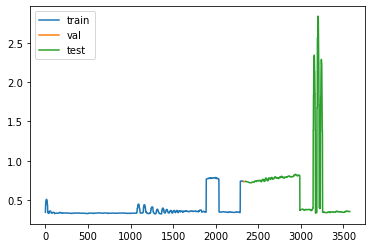

In [41]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

#ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [42]:
path = 'Models/publication/ae/bin/'
cbs.save_all(path,model=m,learn=learn,opt=opt)

  0%|          | 5/2326 [00:00<00:47, 48.81it/s]

testing...


 24%|██▍       | 6/25 [00:00<00:00, 55.63it/s]6it/s]

testing...


  0%|          | 5/1224 [00:00<00:26, 46.30it/s]

...

  0%|          | 2/1224 [00:00<01:01, 19.80it/s]

testing...


 53%|█████▎    | 644/1224 [00:10<00:09, 59.49it/s]

fake


100%|█████████▉| 1221/1224 [00:19<00:00, 61.52it/s]

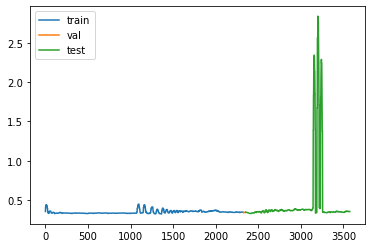

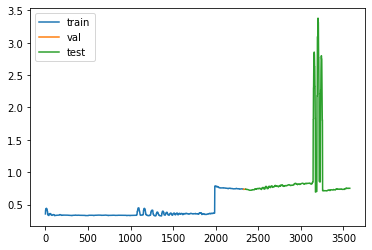

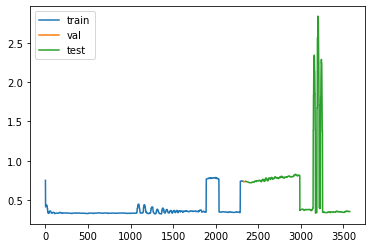

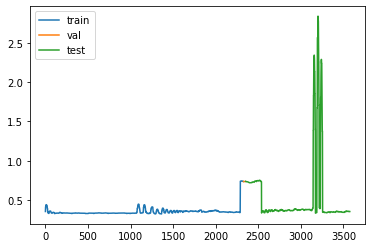

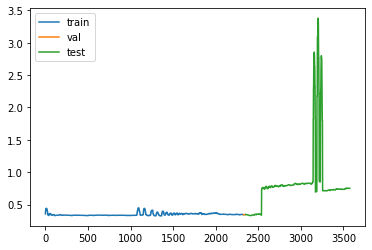

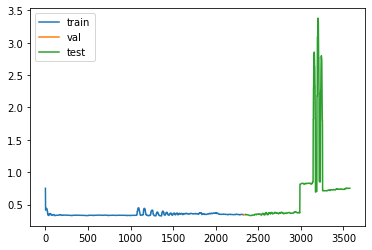

In [43]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.5 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/ae/bin/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

In [218]:
m =  unet_seq(bs,seq_len).cuda()

In [219]:
opt = torch.optim.Adam(m.parameters(),1e-8)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [220]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [221]:
m.lka = torch.zeros_like(m.lka).cuda()

In [222]:
loss = SSIM()

In [223]:
#path = 'documentation/lka/AE without variance/1/'
#cbs.load_all(path,model = m,learn=learn,opt=opt )

In [ ]:
m.max_count = len(trn_dl)+len(v4_val_dl)
learn.fit(m , opt , 8 , dl,loss  ,callbacks=[sched])

  0%|          | 5/2326 [00:00<00:50, 45.82it/s, loss : 0.7322265148162842]

in
[388, 569, 263, 570, 329, 423]


  4%|▍         | 89/2326 [00:01<03:15, 11.42it/s, loss : 0.8408837479152037]Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f9caf4540b8>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f9caf4540b8>>
Traceback (most recent call last):
    w.join()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
  File "/home/amr/anaconda3/envs/t

LKA ON 263


 15%|█▍        | 345/2326 [00:04<00:21, 91.59it/s, loss : 0.8798273501188859]

...

  0%|          | 5/2326 [00:00<00:50, 45.75it/s, loss : 0.7360384464263916]

in
[]


 23%|██▎       | 534/2326 [00:05<00:20, 87.90it/s, loss : 0.8729221758324556]

LKA ON 520


 48%|████▊     | 1110/2326 [00:12<00:13, 87.61it/s, loss : 0.9220250585057714]

In [ ]:
m.lka =torch.zeros(1).cuda()
m.vis_values = []
m.c =0
m.max_count = len(trn_dl)+len(v4_val_dl)+len(v4_anml_dl)
m.lka_values = []

In [ ]:
trn_item.evaluate(model = m , crit = loss)

In [ ]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [ ]:
lka = [i[0][0] for i in m.lka_values]
vis = [i[0][1] for i in m.lka_values]
#diff = [i[0][3] for i in m.lka_values]
op = [i[1][0] for i in m.lka_values]

Dis:It consider normal flow data as anomaly.

In [ ]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
#ax.plot(range(len(diff)),diff)
#ax.plot(range(len(op)),op)


threshold = b[:100].max()
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))
ax.plot(range(len(c),len(c)+len(a)),list(a))
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b))
#ax.plot(range(len(lka)),lka)
ax.plot(range(len(a)+len(b)+len(c)), [threshold]*(len(a)+len(b)+len(c)))

fig,ax = plt.subplots()
ax.plot(range(len(vis)),vis)


In [ ]:
path = 'Models/documentation/lka/AE without variance/run2/1/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

## AE Simplified
Input: VIS + Previous LKA + noise  <br>
Input Form: Decimal <br>
Output: Reconstruction   <br>
Training Dataset: Original<br>

In [46]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(2,2),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(2,4),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(4,2),
                                            nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = []
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        self.art_lka =[]
        #Random normal
        self.m = normal.Normal(0.5244,0.0051)
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = False
        self.max_count= 2352
    def forward(self,x):   
        
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
              
        if self.c==0 and not self.test:
            idx = random.randint(0,8)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(m.lka.type(torch.BoolTensor),torch.ones_like(m.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()
            
        
        
        cat=torch.cat([self.previous_lka,(normalize(self.vis)+self.m.sample())/2,])#.cuda()
        
        predected_lka = self.lka_compressor(cat)
        
        self.previous_vis = self.vis.data.detach()
        self.previous_lka = self.lka.data.detach()
        
        self.lka_values.append([cat,predected_lka.data])
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return cat,predected_lka


In [102]:
m =  unet_seq(bs,seq_len).cuda()

In [103]:
opt = torch.optim.Adam(m.parameters(),1e-5)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [104]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [105]:
loss = mse()

In [106]:
m.max_count = len(trn_dl)+len(v4_val_dl)

In [107]:
cbs.load_all('publication/simplified ae/mse/',learn=learn,model=m,opt=opt)

In [108]:
m.true = False
m.c = 0

In [109]:
learn.fit(m , opt , 1 , dl,loss  ,callbacks=[sched])

  0%|          | 7/2326 [00:00<00:34, 67.40it/s, loss : 0.14091663701193674]

[190]


  9%|▉         | 211/2326 [00:01<00:16, 131.55it/s, loss : 0.16809206777274327]

fake


100%|██████████| 25/25 [00:00<00:00, 116.77it/s, loss : 0.08535077095031739]868]

train Loss:  0.09696628153324127   validation loss:  0.08535076677799225
tensor(nan)


In [110]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = l[2]

In [111]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 10/2326 [00:00<00:24, 95.99it/s]

testing...


  9%|▉         | 214/2326 [00:01<00:15, 138.13it/s]

fake


 23%|██▎       | 529/2326 [00:03<00:12, 140.74it/s]

...

  1%|          | 10/1224 [00:00<00:12, 95.48it/s]

testing...


  6%|▌         | 69/1224 [00:00<00:09, 126.99it/s]

fake


 99%|█████████▉| 1210/1224 [00:08<00:00, 141.98it/s]

In [112]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [113]:
lka = [i[0][0]for i in m.flag_list]

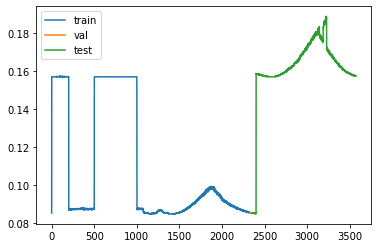

In [114]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

#ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [123]:
path = 'Models/publication/simplified ae/SSIM/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

  0%|          | 8/2326 [00:00<00:29, 78.65it/s]

testing...


 36%|███▌      | 9/25 [00:00<00:00, 81.65it/s]6it/s]

testing...


  1%|          | 9/1224 [00:00<00:14, 86.19it/s]

...

  1%|          | 10/1224 [00:00<00:12, 96.21it/s]

testing...


  6%|▌         | 75/1224 [00:00<00:09, 120.15it/s]

fake


 99%|█████████▉| 1212/1224 [00:09<00:00, 134.58it/s]

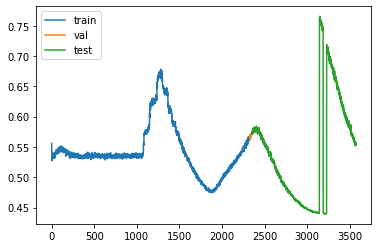

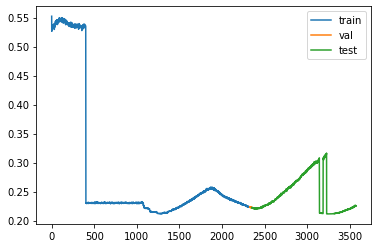

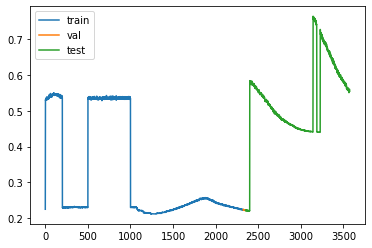

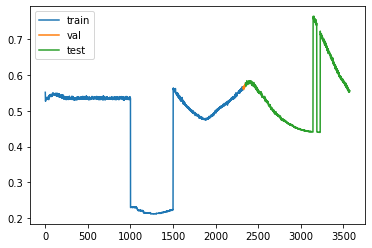

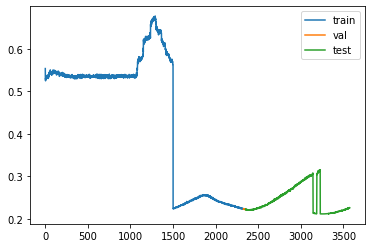

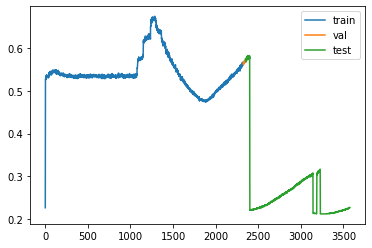

In [124]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.5 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/simplified ae/SSIM/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

In [31]:
m =  unet_seq(bs,seq_len).cuda()

In [32]:
opt = torch.optim.Adam(m.parameters(),1e-8)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [33]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [34]:
m.lka = torch.zeros_like(m.lka).cuda()

In [35]:
loss = SSIM()

In [36]:
path = 'documentation/lka/AE without variance/simplified/1/'
#cbs.load_all(path,model = m,learn=learn,opt=opt )

In [37]:
#m.max_count = len(trn_dl)+len(v4_val_dl)
#learn.fit(m , opt , 2 , dl,loss  ,callbacks=[sched])

In [38]:
m.lka =torch.zeros(1).cuda()
m.vis_values = []
m.c =0
m.max_count = len(trn_dl)+len(v4_val_dl)+len(v4_anml_dl)
m.lka_values = []

In [39]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 1/2326 [00:00<07:07,  5.44it/s]

testing...
in
[498, 332, 366, 336]


 43%|████▎     | 1004/2326 [00:18<00:49, 26.46it/s]

LKA ON 1000


 56%|█████▌    | 1302/2326 [00:23<00:25, 40.07it/s]

LKA OFF 1300


100%|██████████| 2326/2326 [00:41<00:00, 40.55it/s]

In [40]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

 28%|██▊       | 7/25 [00:00<00:00, 67.98it/s]

testing...


  0%|          | 1/1224 [00:00<02:07,  9.57it/s]

testing...


100%|█████████▉| 1218/1224 [00:21<00:00, 27.77it/s]

In [41]:
lka = [i[0][0] for i in m.lka_values]
vis = [i[0][1] for i in m.lka_values]
#diff = [i[0][3] for i in m.lka_values]
op = [i[1][0] for i in m.lka_values]

Dis:It consider normal flow data as anomaly.

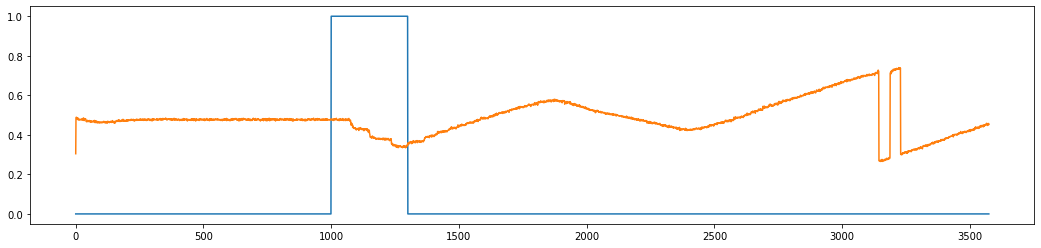

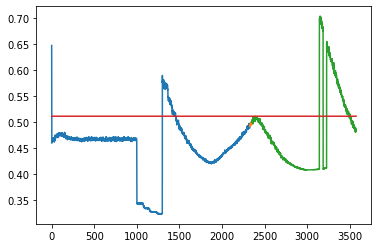

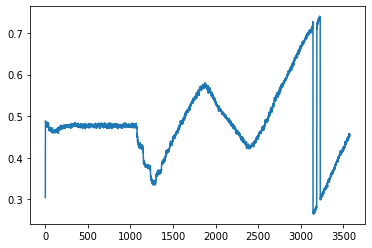

In [42]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
#ax.plot(range(len(diff)),diff)
#ax.plot(range(len(op)),op)


threshold = b[:100].max()
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))
ax.plot(range(len(c),len(c)+len(a)),list(a))
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b))
#ax.plot(range(len(lka)),lka)
ax.plot(range(len(a)+len(b)+len(c)), [threshold]*(len(a)+len(b)+len(c)))

fig,ax = plt.subplots()
ax.plot(range(len(vis)),vis)


In [43]:
path = 'Models/documentation/lka/AE without variance/simplified/1/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

In [47]:
torch.tensor(vis[2500:3000]).std()

tensor(0.0630)

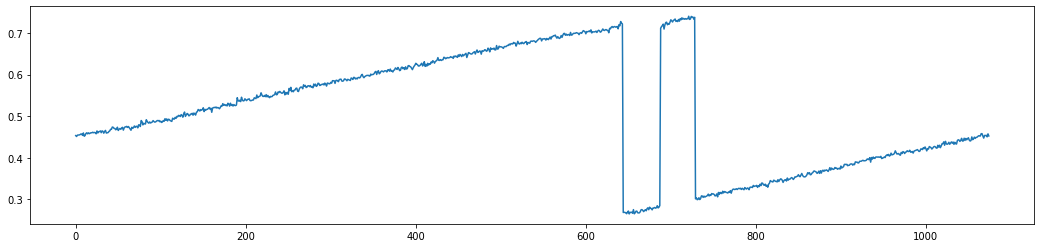

In [46]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(vis[2500:])),vis[2500:])